In [1]:
#Load libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers,Model
from sklearn.preprocessing import StandardScaler

I0000 00:00:1783028261.035999   40605 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#Load the cleaned data

data = pd.read_csv('bad_nauheim.csv')
data.columns

Index(['Unnamed: 0', 'visitors', 'name', 'avgDuration', 'timestamp', 'SID',
       'weekday', 'hour_sin', 'hour_cos'],
      dtype='str')

In [3]:
#Configurations

features = ['visitors','avgDuration','weekday','hour_sin','hour_cos']
n_features = len(features)
window_size = 24

In [4]:
data = data.sort_values(['SID','timestamp'])
data.head()

,Unnamed: 0,visitors,name,avgDuration,timestamp,SID,weekday,hour_sin,hour_cos
28,28,1,Kurpark - Eingang Kurhaus,17.55,2025-06-30 01:00:00+00:00,26213d2d-2954-4312-b42a-a6b323764086,0,0.258819,0.965926
55,55,3,Kurpark - Eingang Kurhaus,4.10,2025-06-30 02:00:00+00:00,26213d2d-2954-4312-b42a-a6b323764086,0,0.500000,0.866025
129,129,3,Kurpark - Eingang Kurhaus,0.75,2025-06-30 03:00:00+00:00,26213d2d-2954-4312-b42a-a6b323764086,0,0.707107,0.707107
194,194,17,Kurpark - Eingang Kurhaus,6.09,2025-06-30 04:00:00+00:00,26213d2d-2954-4312-b42a-a6b323764086,0,0.866025,0.500000
197,197,17,Kurpark - Eingang Kurhaus,6.44,2025-06-30 04:00:00+00:00,26213d2d-2954-4312-b42a-a6b323764086,0,0.866025,0.500000


In [5]:
train_data = []
sensor_ids = []
window_times = []
location = []

for sensor in data['SID'].unique():

    sensor_data = data[data['SID'] == sensor]

    values = sensor_data[features].values
    timestamps = sensor_data["timestamp"].values
    name = sensor_data['name'].values

    for i in range(len(values) - window_size + 1):
        train_data.append(values[i:i+window_size])
        sensor_ids.append(sensor)
        window_times.append(timestamps[i + window_size - 1])
        location.append(name[i + window_size - 1])

train_data = np.array(train_data)

In [6]:
#Standardarizing the data

scaler = StandardScaler()
train_data_reshaped = train_data.reshape(-1,2)
train_data_scaled = scaler.fit_transform(train_data_reshaped)

#Convert our data into normal shape
train_data = train_data_scaled.reshape(-1,24,n_features)
print(train_data.shape)

(16888, 24, 5)


In [7]:
#Plot the loss functions

def loss_function_analysis(history):
    history_dict = history.history
    train_loss = history_dict['loss']
    validation_loss = history_dict['val_loss']
    epoches = [i for i in range(1,len(train_loss)+1)]
    plt.plot(epoches,train_loss,label='Train Loss',color = 'black')
    plt.plot(epoches,validation_loss,label = 'Validation Loss', color = 'red')
    plt.xlabel('Epoches')
    plt.ylabel('Loss')
    plt.title('Loss Function Analysis')
    plt.legend()
    plt.show()

In [8]:
#Build a Autoencoder-LSTM Model

inputs = layers.Input(shape=(window_size,n_features))
x = layers.LSTM(64,return_sequences=True)(inputs)
x = layers.LSTM(32,return_sequences = False)(x)

#Then it is a bottleneck or a latent which saves the compressed knowledge
latent = layers.Dense(16,activation='relu')(x)

x = layers.RepeatVector(window_size)(latent)
x = layers.LSTM(32,return_sequences = True)(x)
x = layers.LSTM(64,return_sequences=True)(x)

outputs = layers.TimeDistributed(layers.Dense(n_features))(x)

model = Model(inputs,outputs)

I0000 00:00:1783028263.385605   40605 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 729 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 5)          │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,293 (243.33 KB)

 Trainable params: 62,293 (243.33 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer = 'adam',loss= 'mse')

In [11]:
history = model.fit(train_data,train_data,
          epochs =30 ,
          batch_size=64,
         validation_split=0.2)

Epoch 1/30


I0000 00:00:1783028267.184135   40691 cuda_dnn.cc:461] Loaded cuDNN version 92300


212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.3007 - val_loss: 0.0853
Epoch 2/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0986 - val_loss: 0.0688
Epoch 3/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0838 - val_loss: 0.0544
Epoch 4/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0706 - val_loss: 0.0623
Epoch 5/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0678 - val_loss: 0.0497
Epoch 6/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0602 - val_loss: 0.0438
Epoch 7/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0617 - val_loss: 0.0472
Epoch 8/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0509 - val_loss: 0.0392
Epoch 9/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0501 - val_loss: 0.0399
Epoch 10/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0496 - val_loss: 0.0354
Epoch 11/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0452 - val_loss: 0.0348
Epoch 12/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/ste

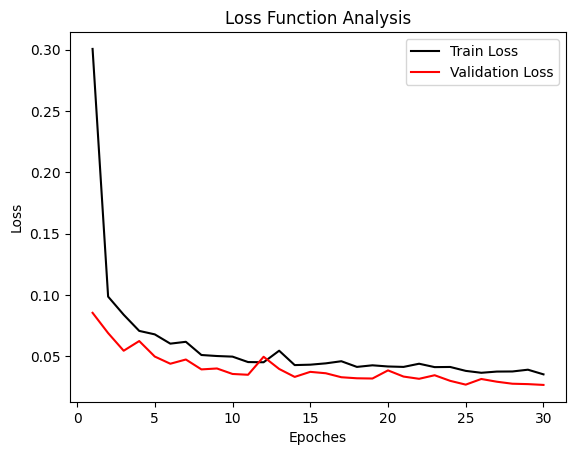

In [12]:
loss_function_analysis(history)

In [13]:
pred = model.predict(train_data)

528/528 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


In [14]:
errors = np.mean(np.square(train_data-pred),axis = (1,2))

In [15]:
errors

array([0.01985628, 0.02026721, 0.02078711, ..., 0.01335725, 0.01293566,
       0.01331249], shape=(16888,))

In [16]:
import pandas as pd

results = pd.DataFrame({
    "SID": sensor_ids,
    "location": location,
    "timestamp": window_times,
    "error": errors
})

In [17]:
results

,SID,location,timestamp,error
0,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 12:00:00+00:00,0.019856
1,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 12:00:00+00:00,0.020267
2,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 12:00:00+00:00,0.020787
3,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 12:00:00+00:00,0.019674
4,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 13:00:00+00:00,0.019259
...,...,...,...,...
16883,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 03:00:00+00:00,0.012112
16884,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 04:00:00+00:00,0.012730
16885,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 21:00:00+00:00,0.013357
16886,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 21:00:00+00:00,0.012936


In [18]:
sensors = list(results['SID'].unique())

In [19]:
#Determine the reconstruction error distribution for each sensor

def reconstruction_error_distribution(sensor_id):
    sensor_data = results[results['SID'] == sensor_id]
    error = sensor_data['error']
    plt.hist(error)
    plt.show()

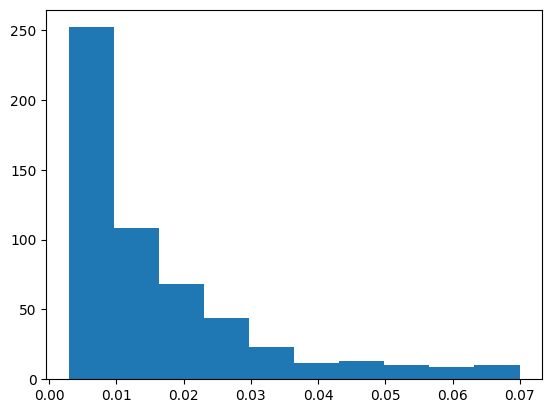

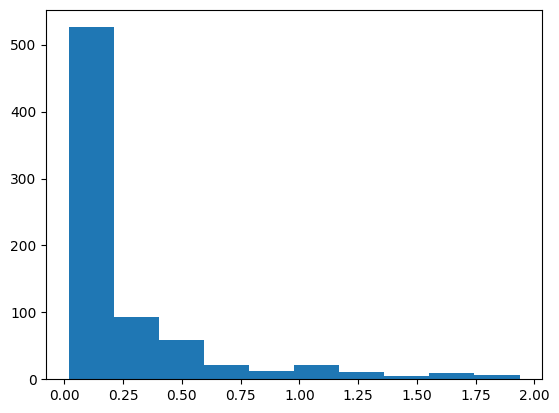

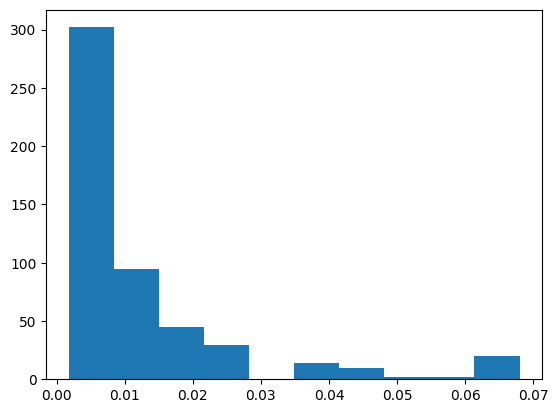

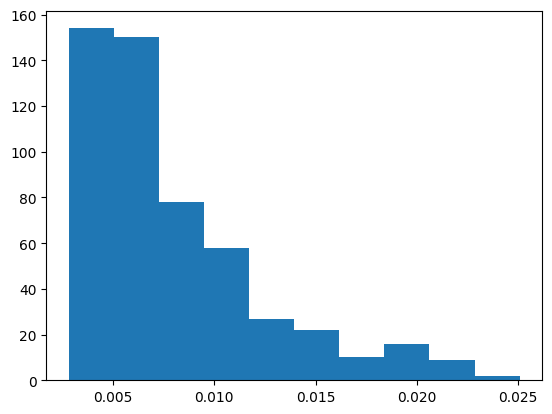

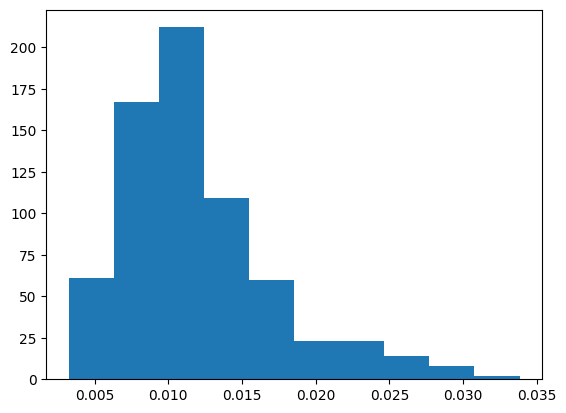

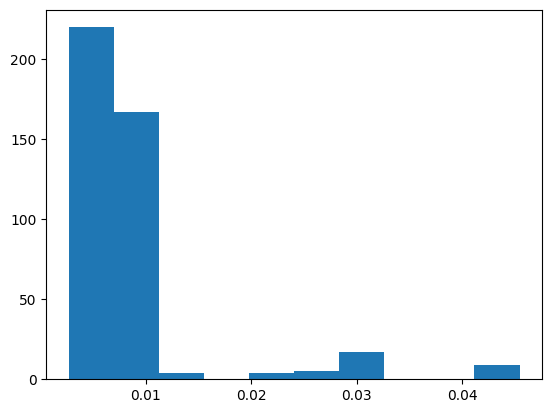

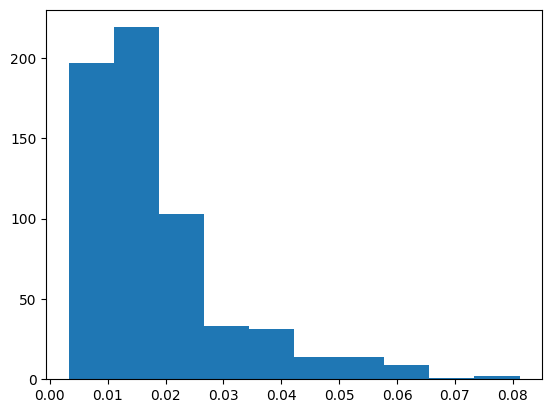

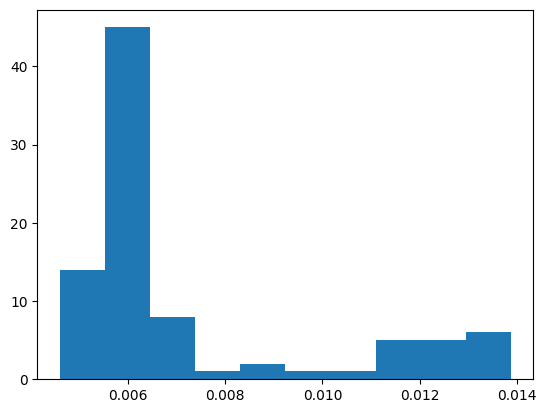

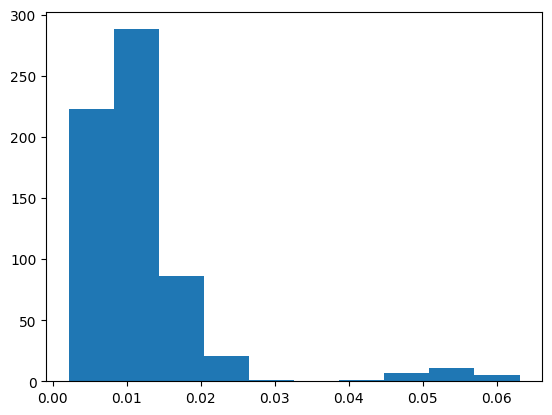

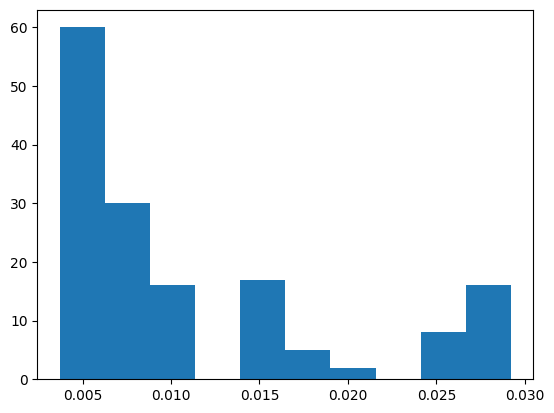

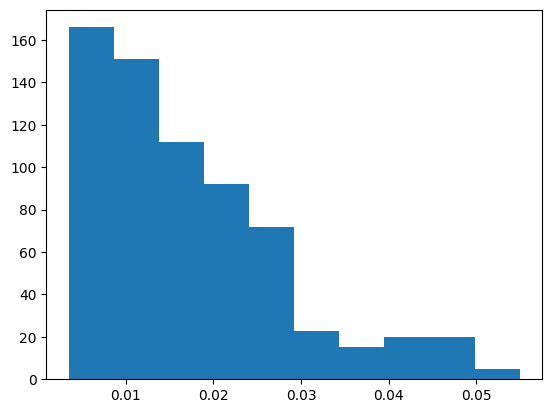

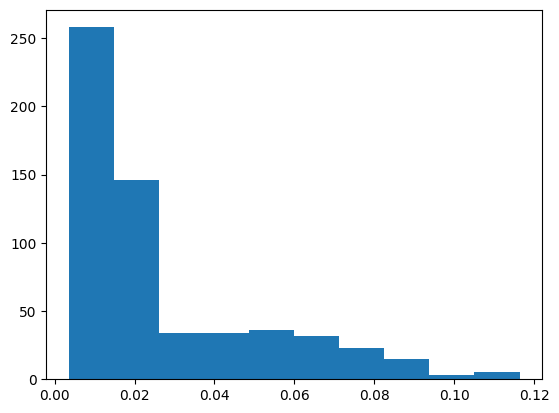

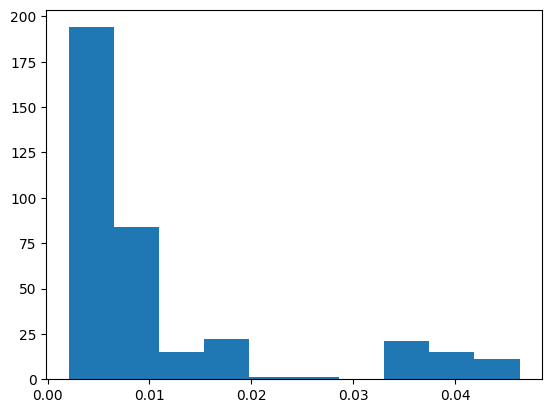

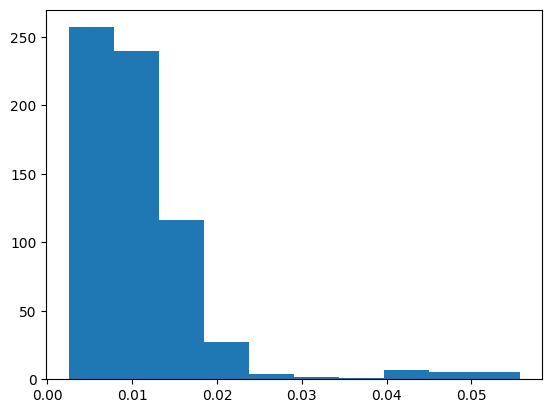

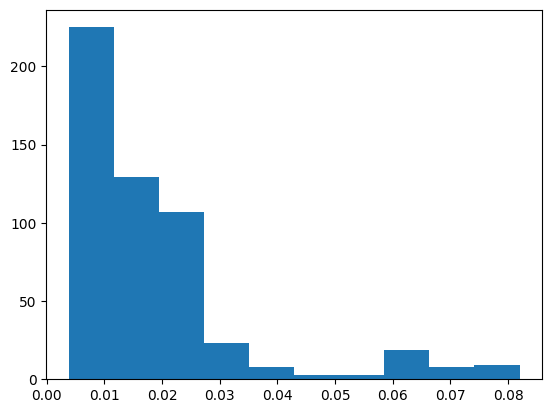

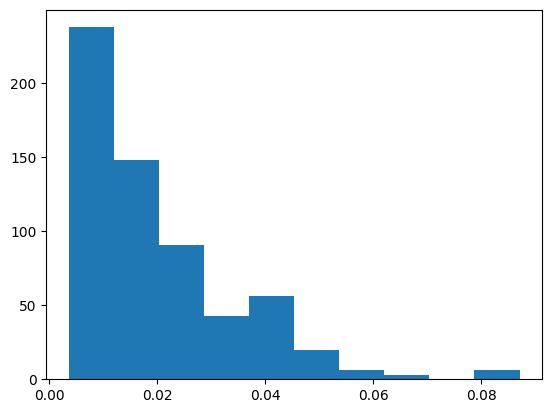

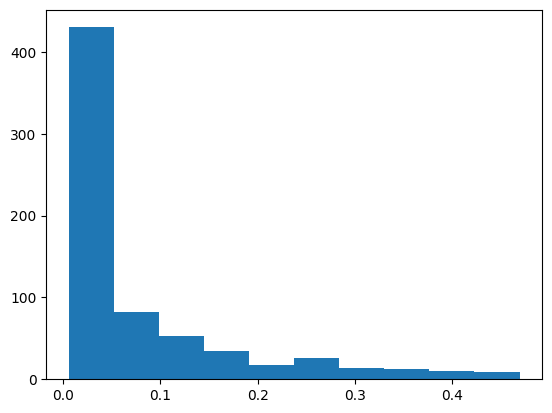

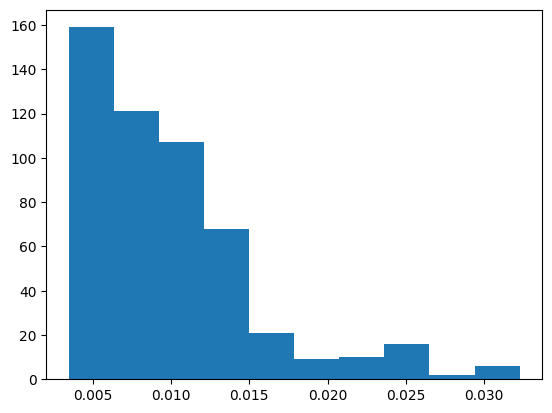

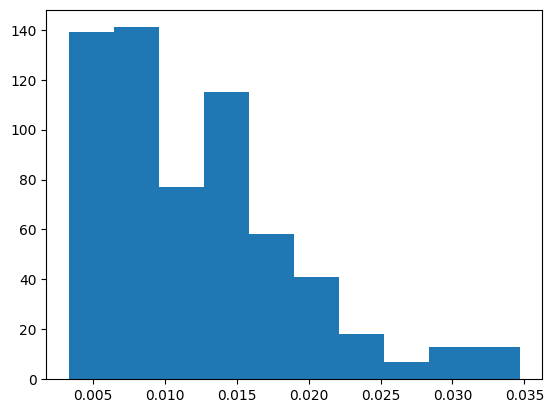

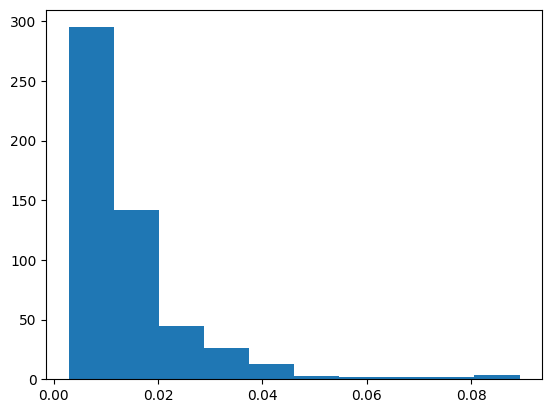

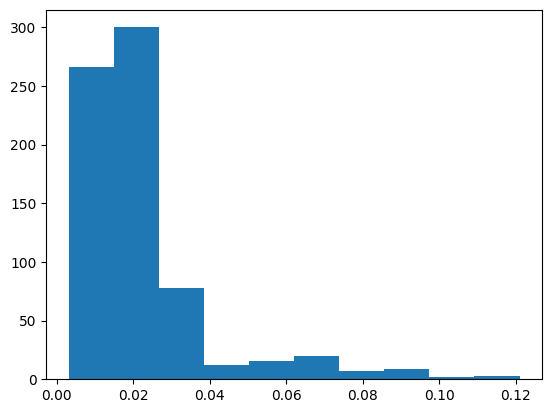

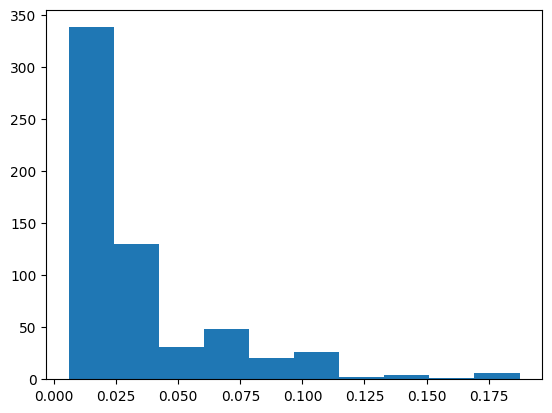

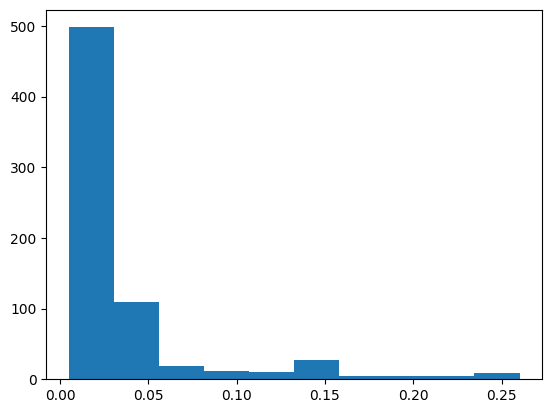

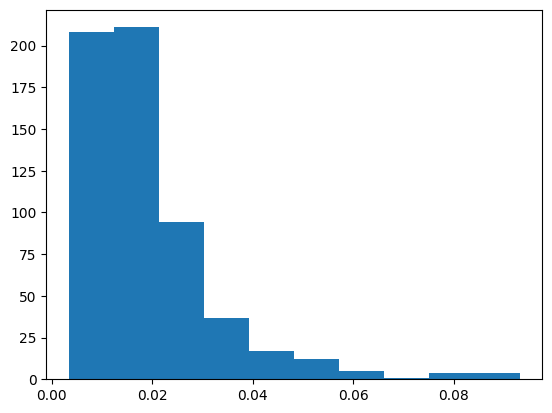

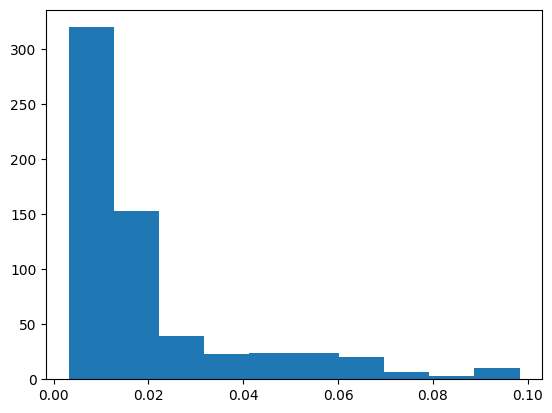

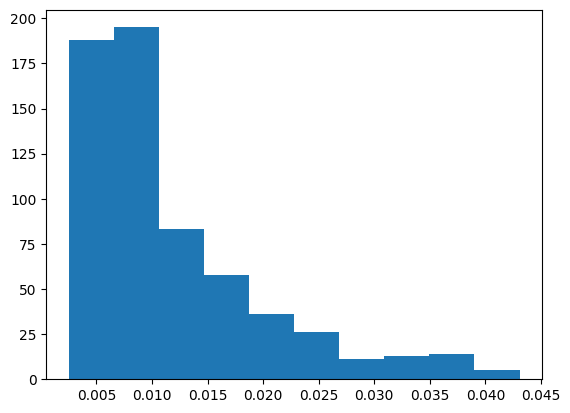

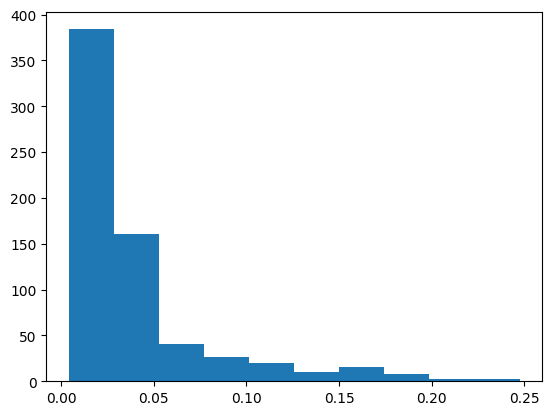

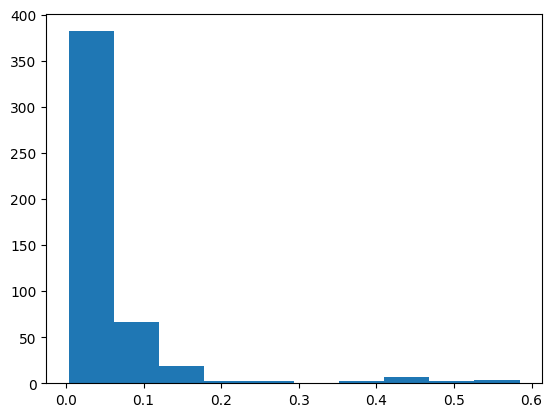

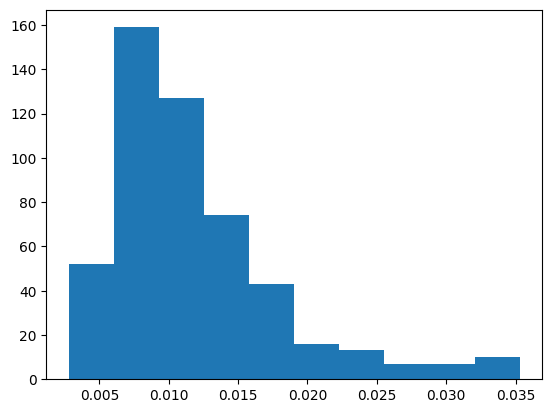

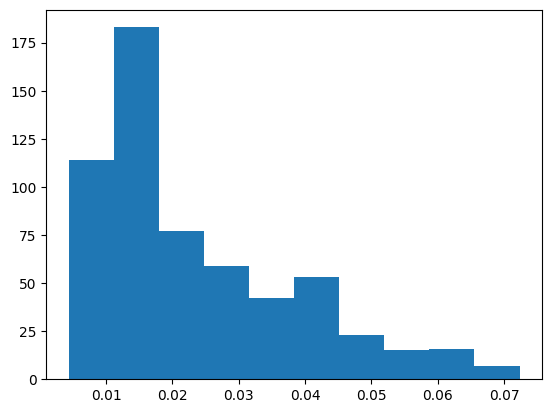

In [20]:
for sensor in sensors:
    reconstruction_error_distribution(sensor)